# PPA Exposure Modelling — Step 1
## Download and validation of historical DK1 spot

**Source:** Energi Data Service (Energinet) — dataset `Elspotprices`  
**Endpoint:** `https://api.energidataservice.dk/dataset/Elspotprices`

**Goal:** download hourly day-ahead DK1 prices from 2021-01-01 to 2026-05-31, aggregate to daily/monthly, validate quality, and save for calibration of the Schwartz model.

**Window:** 5 years + 5 months (deliberately includes the 2022 crisis — the model must capture the stress regime).

**Outputs:**
- `data/spot_dk1_hourly.csv` — original hourly series
- `data/spot_dk1_daily.csv` — daily baseload aggregate (24h mean)
- `data/spot_dk1_monthly.csv` — monthly aggregate

## 1. Imports and configuration

In [3]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [4]:
# Configuration
API_URL = "https://api.energidataservice.dk/dataset/Elspotprices"
START_DATE = "2021-01-01"
END_DATE = "2026-06-04"
PRICE_AREA = "DK1"  # 'DK1' Western Denmark, 'DK2' Eastern

OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Configuration:")
print(f"  Price area : {PRICE_AREA}")
print(f"  Window     : {START_DATE} -> {END_DATE}")
print(f"  Output dir : {OUTPUT_DIR.resolve()}")

Configuration:
  Price area : DK1
  Window     : 2021-01-01 -> 2026-06-04
  Output dir : C:\Users\jorge\OneDrive - Danmarks Tekniske Universitet\Jorge Grau\Jorge Grau\APP assesment\Orsted\Github\ppa-exposure-modelling\notebooks\data


## 2. Download function (paginated)

The API limits records per call, so we paginate until we exhaust the window.

In [5]:
import time

API_BASE = "https://api.energidataservice.dk/dataset"
LEGACY_CUTOFF = pd.Timestamp("2025-09-30")  # Elspotprices stopped here

HEADERS = {
    "User-Agent": "PPA-Exposure-Prototype/1.0 (research, jorge)",
    "Accept": "application/json",
}


def _get_with_retry(url, params, max_retries=5):
    """GET with exponential backoff on 429 / 5xx."""
    for attempt in range(max_retries):
        response = requests.get(url, params=params, headers=HEADERS, timeout=60)
        if response.status_code == 429:
            wait = 10 * (2 ** attempt)
            print(f"  429. Waiting {wait}s (retry {attempt+1}/{max_retries})...")
            time.sleep(wait)
            continue
        if response.status_code >= 500:
            wait = 5 * (2 ** attempt)
            time.sleep(wait)
            continue
        response.raise_for_status()
        return response
    raise RuntimeError(f"Max retries exceeded for {url}")


def _fetch_paginated(dataset: str, start: str, end: str, price_area: str,
                     time_col: str, page_size: int = 50_000) -> pd.DataFrame:
    """Paginated fetch from a given dataset."""
    url = f"{API_BASE}/{dataset}"
    all_records, offset = [], 0
    while True:
        params = {
            "offset": offset, "limit": page_size,
            "start": start, "end": end,
            "filter": json.dumps({"PriceArea": price_area}, separators=(",", ":")),
            "sort": f"{time_col} ASC",
        }
        response = _get_with_retry(url, params)
        records = response.json().get("records", [])
        if not records:
            break
        all_records.extend(records)
        print(f"  [{dataset}] {len(all_records):,} records...")
        if len(records) < page_size:
            break
        offset += page_size
        time.sleep(1.0)
    return pd.DataFrame(all_records)


def fetch_spot_prices(start_date: str, end_date: str, price_area: str = "DK1") -> pd.DataFrame:
    """
    Fetch hourly day-ahead spot prices, stitching legacy Elspotprices and current
    DayAheadPrices datasets. Elspotprices was discontinued at 2025-09-30; the
    successor DayAheadPrices uses 15-min resolution (EU MTU transition), which we
    aggregate back to hourly for consistency.
    """
    start, end = pd.Timestamp(start_date), pd.Timestamp(end_date)
    parts = []

    # --- Legacy: Elspotprices (hourly) ---
    if start <= LEGACY_CUTOFF:
        end_legacy = min(end, LEGACY_CUTOFF)
        print(f"Elspotprices: {start.date()} -> {end_legacy.date()}")
        df = _fetch_paginated(
            "Elspotprices",
            str(start.date()),
            str(end_legacy.date() + pd.Timedelta(days=1)),
            price_area, time_col="HourUTC",
        )
        if not df.empty:
            df["HourUTC"] = pd.to_datetime(df["HourUTC"])
            df["HourDK"] = pd.to_datetime(df["HourDK"])
            df = df[["HourUTC", "HourDK", "PriceArea", "SpotPriceEUR", "SpotPriceDKK"]]
            parts.append(df)
            print(f"  Got {len(df):,} hourly records.\n")

    # --- Current: DayAheadPrices (15-min, agg to hourly) ---
    if end > LEGACY_CUTOFF:
        start_current = max(start, LEGACY_CUTOFF + pd.Timedelta(days=1))
        print(f"DayAheadPrices: {start_current.date()} -> {end.date()}")
        df = _fetch_paginated(
            "DayAheadPrices",
            str(start_current.date()),
            str(end.date() + pd.Timedelta(days=1)),
            price_area, time_col="TimeUTC",
        )
        if not df.empty:
            df["TimeUTC"] = pd.to_datetime(df["TimeUTC"])
            df["TimeDK"] = pd.to_datetime(df["TimeDK"])
            # Aggregate 15-min -> hourly (mean across the 4 quarter-hours of each hour)
            df["HourUTC"] = df["TimeUTC"].dt.floor("h")
            df["HourDK"] = df["TimeDK"].dt.floor("h")
            hourly = (
                df.groupby(["HourUTC", "HourDK", "PriceArea"], as_index=False)
                  .agg(
                      SpotPriceEUR=("DayAheadPriceEUR", "mean"),
                      SpotPriceDKK=("DayAheadPriceDKK", "mean"),
                  )
            )
            parts.append(hourly)
            print(f"  {len(df):,} sub-hourly -> {len(hourly):,} hourly records.\n")

    if not parts:
        raise RuntimeError(f"No data for {price_area} {start_date} -> {end_date}")

    combined = (
        pd.concat(parts, ignore_index=True)
          .drop_duplicates(subset=["HourUTC", "PriceArea"])
          .sort_values("HourUTC")
          .reset_index(drop=True)
    )
    return combined

## 3. Download and first inspection

In [6]:
hourly = fetch_spot_prices(START_DATE, END_DATE, PRICE_AREA)
print(f"\nTotal hourly records: {len(hourly):,}")
hourly.head()

Elspotprices: 2021-01-01 -> 2025-09-30
  [Elspotprices] 41,615 records...
  Got 41,615 hourly records.

DayAheadPrices: 2025-10-01 -> 2026-06-04
  [DayAheadPrices] 23,712 records...
  23,712 sub-hourly -> 5,928 hourly records.


Total hourly records: 47,543


,HourUTC,HourDK,PriceArea,SpotPriceEUR,SpotPriceDKK
0,2020-12-31 23:00:00,2021-01-01 00:00:00,DK1,50.869999,378.519989
1,2021-01-01 00:00:00,2021-01-01 01:00:00,DK1,48.189999,358.579987
2,2021-01-01 01:00:00,2021-01-01 02:00:00,DK1,44.680000,332.459991
3,2021-01-01 02:00:00,2021-01-01 03:00:00,DK1,42.919998,319.369995
4,2021-01-01 03:00:00,2021-01-01 04:00:00,DK1,40.389999,300.540009


In [7]:
hourly.info()

<class 'pandas.DataFrame'>
RangeIndex: 47543 entries, 0 to 47542
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   HourUTC       47543 non-null  datetime64[us]
 1   HourDK        47543 non-null  datetime64[us]
 2   PriceArea     47543 non-null  str           
 3   SpotPriceEUR  47543 non-null  float64       
 4   SpotPriceDKK  47543 non-null  float64       
dtypes: datetime64[us](2), float64(2), str(1)
memory usage: 2.0 MB


In [8]:
# Missing values?
hourly.isna().sum()

HourUTC         0
HourDK          0
PriceArea       0
SpotPriceEUR    0
SpotPriceDKK    0
dtype: int64

## 4. Aggregation to daily frequency (baseload)

The daily baseload price = mean of the 24 hours of the day. This is the frequency at which we calibrate the Schwartz model (we can move to monthly later).

In [9]:
def aggregate_to_daily(hourly: pd.DataFrame) -> pd.DataFrame:
    daily = (
        hourly.assign(Date=hourly["HourDK"].dt.date)
        .groupby("Date", as_index=False)
        .agg(
            SpotPriceEUR=("SpotPriceEUR", "mean"),
            SpotPriceDKK=("SpotPriceDKK", "mean"),
            HoursAvailable=("HourUTC", "count"),
        )
    )
    daily["Date"] = pd.to_datetime(daily["Date"])
    return daily

daily = aggregate_to_daily(hourly)
print(f"Total days: {len(daily):,}")
daily.head()
daily.tail()

Total days: 1,981


,Date,SpotPriceEUR,SpotPriceDKK,HoursAvailable
1976,2026-05-31,94.084375,703.101943,24
1977,2026-06-01,151.864688,1134.991115,24
1978,2026-06-02,122.185416,913.213802,24
1979,2026-06-03,103.440416,773.103327,24
1980,2026-06-04,63.484687,474.497251,24


## 5. Visualisation of the daily series

The "eyeball test": we expect to see low levels pre-2022, the 2022 spike, and progressive normalisation in 2023-2025.

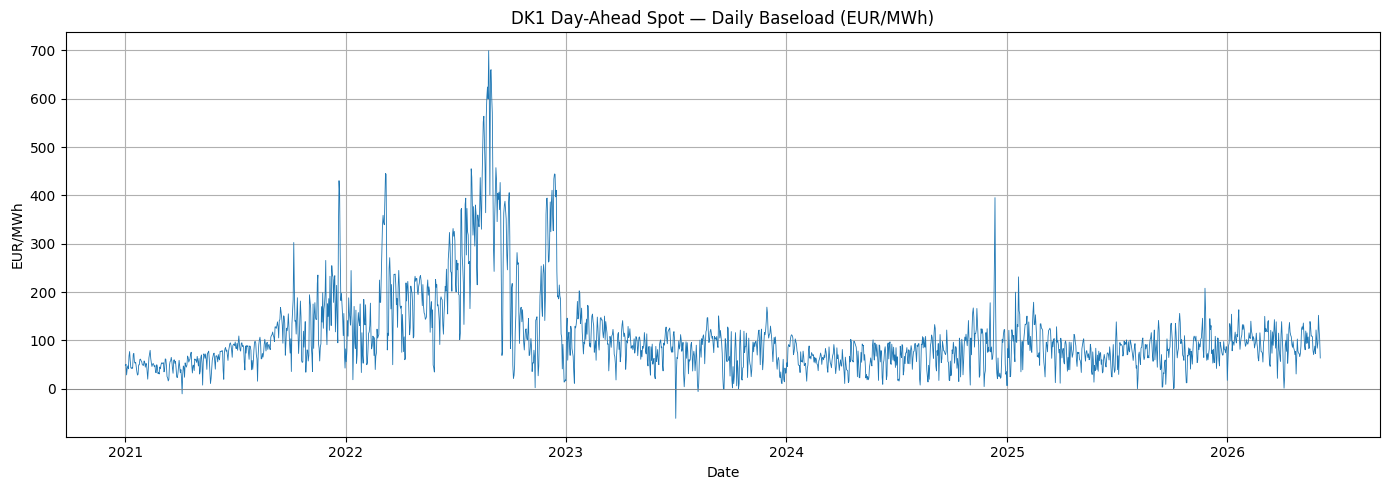

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["Date"], daily["SpotPriceEUR"], linewidth=0.6, color="#1f77b4")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title(f"{PRICE_AREA} Day-Ahead Spot — Daily Baseload (EUR/MWh)")
ax.set_xlabel("Date")
ax.set_ylabel("EUR/MWh")
plt.tight_layout()
plt.show()

c:\Users\jorge\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


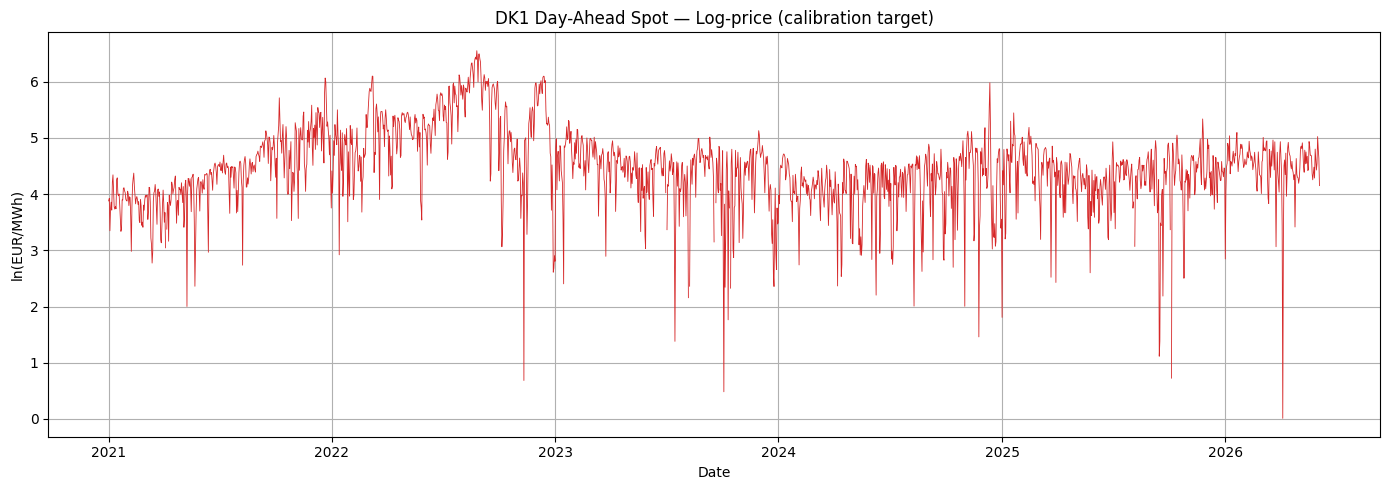

In [11]:
# Log-price: what the Schwartz model treats as an OU process.
# Not defined for prices <= 0; we mark them as NaN here (handled later).
daily["LogSpotPriceEUR"] = np.where(
    daily["SpotPriceEUR"] > 0,
    np.log(daily["SpotPriceEUR"]),
    np.nan,
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily["Date"], daily["LogSpotPriceEUR"], linewidth=0.6, color="#d62728")
ax.set_title(f"{PRICE_AREA} Day-Ahead Spot — Log-price (calibration target)")
ax.set_xlabel("Date")
ax.set_ylabel("ln(EUR/MWh)")
plt.tight_layout()
plt.show()

## 6. Sanity checks

Numbers we need to know and that will go into the technical document:
- Days with negative price (renewable penetration)
- Days in crisis territory (>300 EUR/MWh)
- Days with != 24 hours (DST, data gaps)
- Overall distribution

In [12]:
print("=== Statistical summary (EUR/MWh) ===")
print(daily["SpotPriceEUR"].describe().round(2).to_string())

print("\n=== Data quality ===")
print(f"Date range          : {daily['Date'].min().date()} -> {daily['Date'].max().date()}")
print(f"Total days          : {len(daily):,}")
print(f"Days with price <= 0 : {(daily['SpotPriceEUR'] <= 0).sum()}")
print(f"Days with price >300 : {(daily['SpotPriceEUR'] > 300).sum()}  (2022 crisis territory)")
print(f"Days with != 24h    : {(daily['HoursAvailable'] != 24).sum()}  (DST expected ~2/year)")

=== Statistical summary (EUR/MWh) ===
count    1981.00
mean      108.17
std        86.30
min       -61.41
25%        60.01
50%        87.55
75%       121.42
max       699.44

=== Data quality ===
Date range          : 2021-01-01 -> 2026-06-04
Total days          : 1,981
Days with price <= 0 : 8
Days with price >300 : 95  (2022 crisis territory)
Days with != 24h    : 11  (DST expected ~2/year)


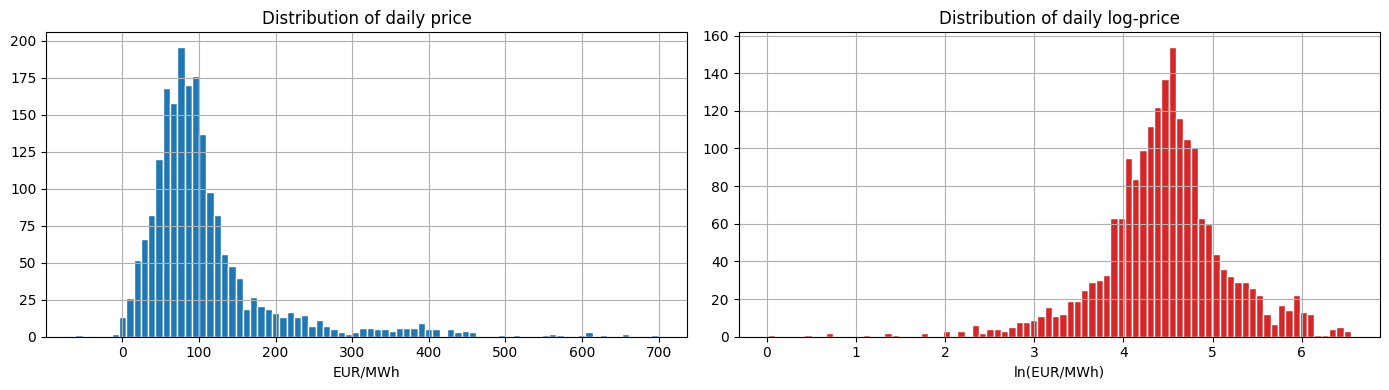

In [13]:
# Histogram of daily prices
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(daily["SpotPriceEUR"], bins=80, color="#1f77b4", edgecolor="white")
axes[0].set_title("Distribution of daily price")
axes[0].set_xlabel("EUR/MWh")

axes[1].hist(daily["LogSpotPriceEUR"].dropna(), bins=80, color="#d62728", edgecolor="white")
axes[1].set_title("Distribution of daily log-price")
axes[1].set_xlabel("ln(EUR/MWh)")
plt.tight_layout()
plt.show()

## 7. Seasonal pattern

To calibrate the seasonal function $f(t)$ of the Schwartz model we need to see the month-by-month pattern. Expectation: winter months more expensive than summer.

In [14]:
daily["Year"] = daily["Date"].dt.year
daily["Month"] = daily["Date"].dt.month

monthly_pattern = (
    daily.groupby("Month")["SpotPriceEUR"].agg(["mean", "median", "std"]).round(2)
)
monthly_pattern

,mean,median,std
Month,,,
1,93.17,89.34,44.69
2,90.83,86.22,39.20
3,103.77,83.36,77.54
4,87.56,77.85,48.94
5,87.14,75.54,50.56
6,100.89,80.57,67.47
7,112.94,84.97,93.77
8,154.39,91.69,164.89
9,139.41,104.08,117.32


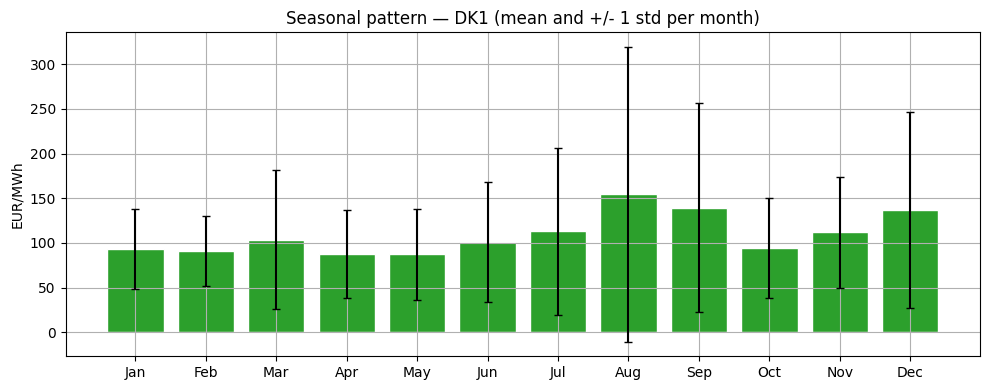

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_pattern.index, monthly_pattern["mean"], color="#2ca02c", edgecolor="white")
ax.errorbar(monthly_pattern.index, monthly_pattern["mean"], yerr=monthly_pattern["std"], fmt="none", color="black", capsize=3)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title(f"Seasonal pattern — {PRICE_AREA} (mean and +/- 1 std per month)")
ax.set_ylabel("EUR/MWh")
plt.tight_layout()
plt.show()

## 8. Monthly aggregation and plot

This is the natural frequency of the PPA (monthly settlement).

In [16]:
def aggregate_to_monthly(daily: pd.DataFrame) -> pd.DataFrame:
    monthly = (
        daily.assign(YearMonth=daily["Date"].dt.to_period("M"))
        .groupby("YearMonth", as_index=False)
        .agg(
            SpotPriceEUR=("SpotPriceEUR", "mean"),
            DaysInMonth=("Date", "count"),
        )
    )
    monthly["YearMonth"] = monthly["YearMonth"].dt.to_timestamp()
    return monthly

monthly = aggregate_to_monthly(daily)
print(f"Total months: {len(monthly)}")
monthly.head()

Total months: 66


,YearMonth,SpotPriceEUR,DaysInMonth
0,2021-01-01,50.205108,31
1,2021-02-01,47.261503,28
2,2021-03-01,45.077861,31
3,2021-04-01,47.967111,30
4,2021-05-01,54.307567,31


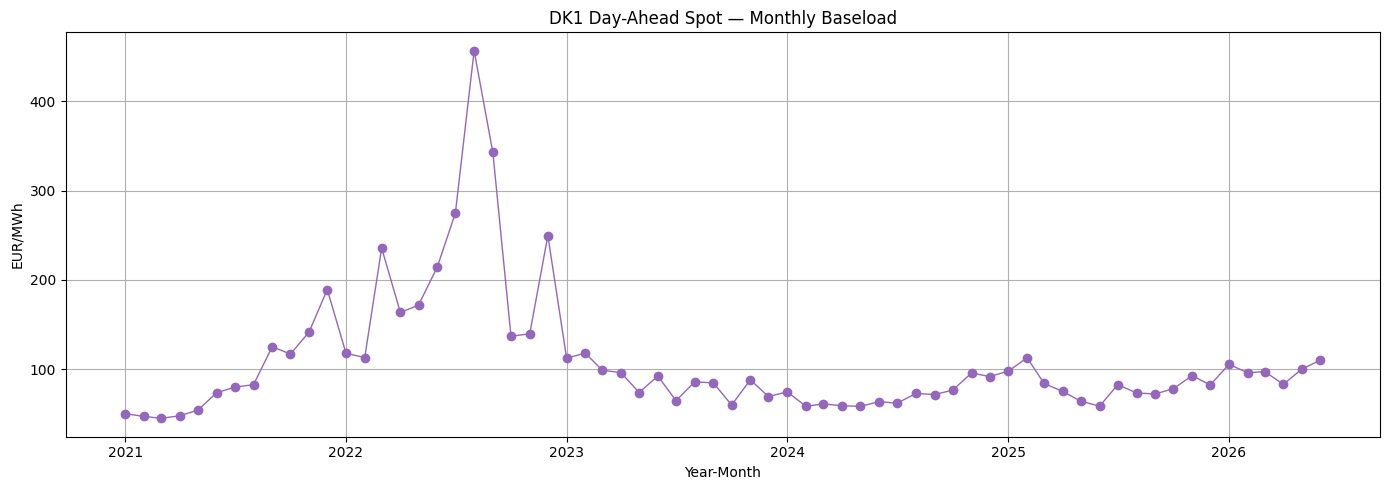

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["YearMonth"], monthly["SpotPriceEUR"], marker="o", linewidth=1, color="#9467bd")
ax.set_title(f"{PRICE_AREA} Day-Ahead Spot — Monthly Baseload")
ax.set_xlabel("Year-Month")
ax.set_ylabel("EUR/MWh")
plt.tight_layout()
plt.show()

## 9. Save versioned files

In [18]:
tag = f"{PRICE_AREA.lower()}_{START_DATE}_{END_DATE}"
out_hourly = OUTPUT_DIR / f"spot_{tag}_hourly.csv"
out_daily = OUTPUT_DIR / f"spot_{tag}_daily.csv"
out_monthly = OUTPUT_DIR / f"spot_{tag}_monthly.csv"

hourly.to_csv(out_hourly, index=False)
daily.drop(columns=["Year", "Month"]).to_csv(out_daily, index=False)
monthly.to_csv(out_monthly, index=False)

print("Saved:")
for p in [out_hourly, out_daily, out_monthly]:
    print(f"  {p}  ({p.stat().st_size / 1024:.1f} KB)")

Saved:
  data\spot_dk1_2021-01-01_2026-06-04_hourly.csv  (3045.7 KB)
  data\spot_dk1_2021-01-01_2026-06-04_daily.csv  (130.2 KB)
  data\spot_dk1_2021-01-01_2026-06-04_monthly.csv  (2.2 KB)


## 10. Checklist for the technical document

Make sure you have noted from this step:

| Item | Value |
|------|-------|
| Source | Energi Data Service (Energinet) |
| Dataset | Elspotprices |
| Price area | DK1 |
| Window | 2021-01-01 to 2026-05-31 |
| Hourly records | (fill in) |
| Total days | (fill in) |
| Mean daily EUR/MWh | (fill in) |
| Std daily EUR/MWh | (fill in) |
| Days with negative price | (fill in) |
| Days > 300 EUR/MWh | (fill in) |
| Outlier treatment | None (full series kept, including 2022) |
| Negative-price treatment | Marked as NaN in log-price; shift constant for calibration (defined in step 2) |

Next step: download the EEX forward curve and build the 5-year monthly curve via seasonal bootstrap.